# Mode 01: Z24 raw PDT cleaning

> This Mode 01 notebook requires `sources-Z24-004.zip`. The processed `dataset.zip` workflow is under `../modes02/`.

This notebook cleans the Progressive Damage Test (PDT) data. The condition directory (01--17) is stored as the class label. It keeps measurement type, setup, and channel metadata.

Run the full export cell to process all PDT recordings. The smoke test is optional and commented out.


In [1]:
import torch
import tensorflow as tf

print("PyTorch CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("TensorFlow GPUs:")
print(tf.config.list_physical_devices("GPU"))

PyTorch CUDA: False
TensorFlow GPUs:
[]


In [2]:
from pathlib import Path
import sys
import json
from datetime import datetime

search_paths = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in search_paths if (p / 'src' / 'data' / 'pdt_cleaning.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the shm project.')
sys.path.insert(0, str(ROOT))
from src.data.pdt_cleaning import clean_pdt, SCENARIO_LABELS

raw_candidates = list((ROOT / 'raw_data').glob('sources-Z24*.zip'))
if not raw_candidates:
    raise FileNotFoundError('Download sources-Z24.zip from the data guide and place it in raw_data/.')
ARCHIVE = max(raw_candidates, key=lambda p: p.stat().st_size)
print('Project:', ROOT)
print('Archive exists:', ARCHIVE.exists())


Project: c:\Users\phuotran\Data\research\shm
Archive exists: True


## Full cleaning runs

AVT and FVT run in separate cells. Run only the measurement you need. Every recording prints progress, and `status.json` shows whether a run is still running or complete.


In [3]:
MAX_CONDITIONS = None
MAX_SETUPS = None

def run_cleaning(measurement):
    run_time = datetime.now()
    run_name = run_time.strftime("%d/%m/%Y %H:%M:%S")
    folder_name = run_time.strftime(f"{measurement}_%d-%m-%Y_%H-%M-%S")
    output = ROOT / "processed" / measurement / folder_name
    print(f"Starting {measurement.upper()} run: {run_name}")
    print(f"Output: {output}")
    report = clean_pdt(ARCHIVE, output, measurement=measurement,
                       max_conditions=MAX_CONDITIONS, max_setups=MAX_SETUPS,
                       progress=True)
    report["run_name"] = run_name
    report["output_folder"] = str(output)
    (output / "report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
    print(f"Completed: {report['recordings']} recordings, {report['csv_files']} CSV files")
    return report


### Run AVT only


In [4]:
avt_report = run_cleaning("avt")


Starting AVT run: 20/09/2026 22:22:17
Output: c:\Users\phuotran\Data\research\shm\processed\avt\avt_20-09-2026_22-22-17
[READ] pdt_01-08.zip::01/avt/01setup01.mat


[AVT] condition 01, setup 01: 65530 samples -> 11 CSV files (1 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup02.mat
[AVT] condition 01, setup 02: 65530 samples -> 11 CSV files (2 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup03.mat
[AVT] condition 01, setup 03: 65530 samples -> 11 CSV files (3 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup04.mat
[AVT] condition 01, setup 04: 65530 samples -> 11 CSV files (4 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup05.mat
[AVT] condition 01, setup 05: 65530 samples -> 11 CSV files (5 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup06.mat
[AVT] condition 01, setup 06: 65530 samples -> 11 CSV files (6 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup07.mat
[AVT] condition 01, setup 07: 65530 samples -> 11 CSV files (7 recordings complete)
[READ] pdt_01-08.zip::01/avt/01setup08.mat
[AVT] condition 01, setup 08: 65530 samples -> 11 CSV files (8 recordings complete)
[READ] pdt_01-08.zip::01/av

### Run FVT only


In [5]:
fvt_report = run_cleaning("fvt")


Starting FVT run: 20/09/2026 22:24:34
Output: c:\Users\phuotran\Data\research\shm\processed\fvt\fvt_20-09-2026_22-24-34
[READ] pdt_01-08.zip::01/fvt/01setup01.mat
[FVT] condition 01, setup 01: 65530 samples -> 11 CSV files (1 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup02.mat
[FVT] condition 01, setup 02: 65530 samples -> 11 CSV files (2 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup03.mat
[FVT] condition 01, setup 03: 65530 samples -> 11 CSV files (3 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup04.mat
[FVT] condition 01, setup 04: 65530 samples -> 11 CSV files (4 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup05.mat
[FVT] condition 01, setup 05: 65530 samples -> 11 CSV files (5 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup06.mat
[FVT] condition 01, setup 06: 65530 samples -> 11 CSV files (6 recordings complete)
[READ] pdt_01-08.zip::01/fvt/01setup07.mat
[FVT] condition 01, setup 07: 65530 samples -> 11 CSV files (7 recordings c

## Labels

`condition_id` is the directory number and `label = condition_id - 1`. The descriptive names below come from the official Z24 progressive-damage scenario table. Conditions 1, 2, and 8 are reference/transition conditions, so do not silently collapse them into a healthy class without defining that rule in the paper.


In [6]:
for condition, name in SCENARIO_LABELS.items():
    print(f'{condition:02d} -> label {condition - 1:02d}: {name}')


01 -> label 00: undamaged_reference_1
02 -> label 01: pier_settlement_system_installation
03 -> label 02: pier_settlement_20mm
04 -> label 03: pier_settlement_40mm
05 -> label 04: pier_settlement_80mm
06 -> label 05: pier_settlement_95mm
07 -> label 06: foundation_tilt
08 -> label 07: undamaged_reference_3
09 -> label 08: concrete_spalling_12m2
10 -> label 09: concrete_spalling_24m2
11 -> label 10: abutment_landslide_1m
12 -> label 11: concrete_hinge_failure
13 -> label 12: failure_2_anchor_heads
14 -> label 13: failure_4_anchor_heads
15 -> label 14: tendon_rupture_2_of_16
16 -> label 15: tendon_rupture_4_of_16
17 -> label 16: tendon_rupture_6_of_16


## Visual checks

These charts show how many recordings exist for each condition and what a sensor time series looks like. They read only one CSV for the signal plots, so they do not reload the full dataset.


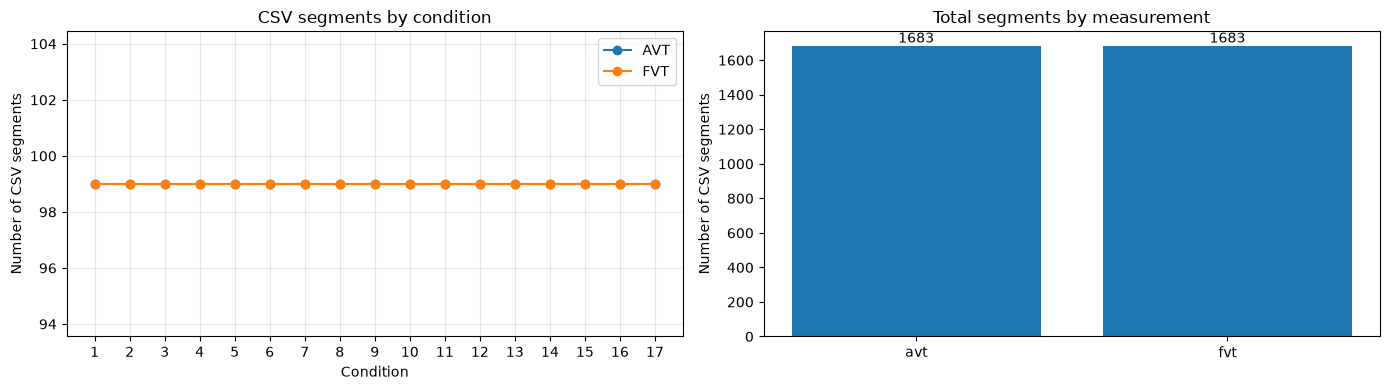

AVT common channels (5): ['R1V', 'R2L', 'R2T', 'R2V', 'R3V']


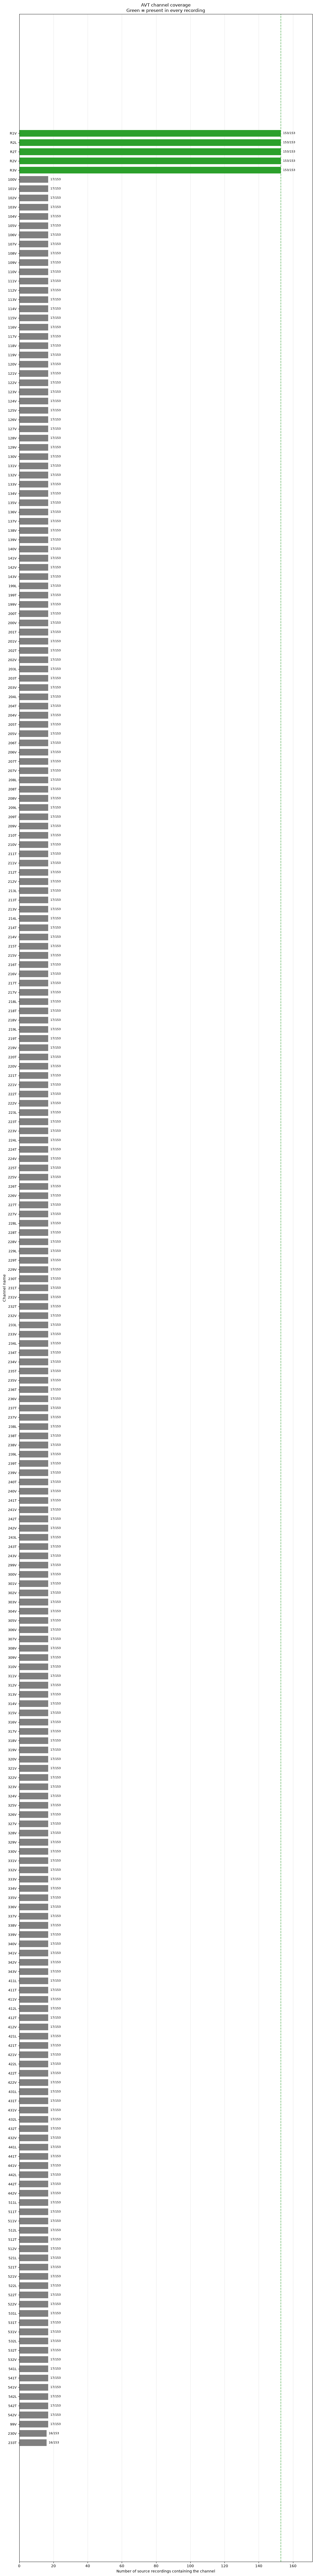

FVT common channels (5): ['R1V', 'R2L', 'R2T', 'R2V', 'R3V']


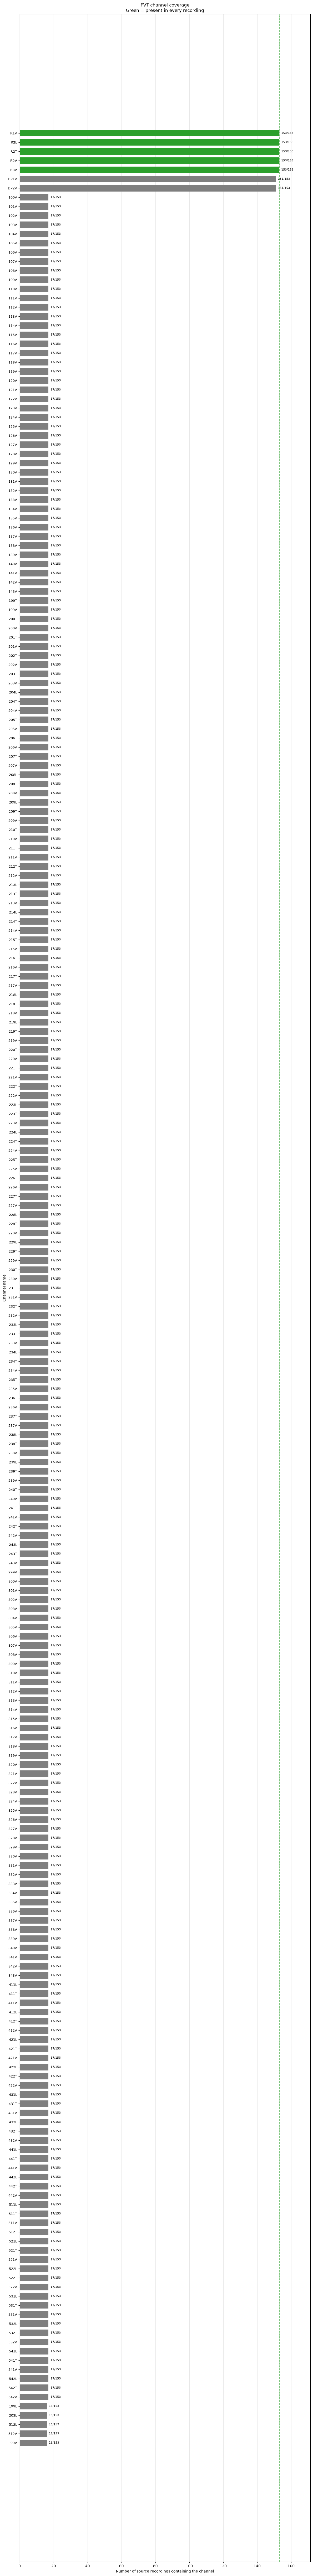

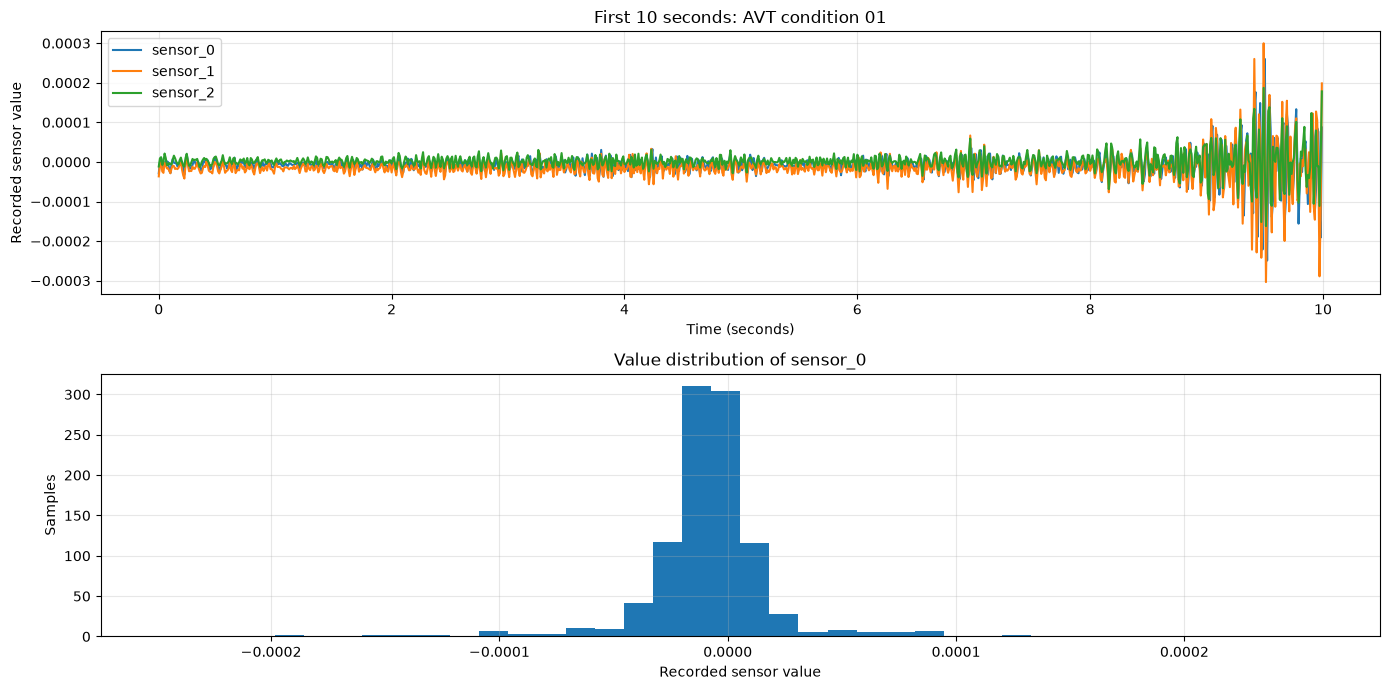

In [8]:
from collections import Counter
import csv
import matplotlib.pyplot as plt
import numpy as np

RUNS = {}
MANIFESTS = {}
for measurement in ("avt", "fvt"):
    candidates = [p for p in (ROOT / "processed" / measurement).glob("*") if (p / "manifest.json").exists()]
    if not candidates:
        continue
    RUNS[measurement] = max(candidates, key=lambda p: p.stat().st_mtime)
    MANIFESTS[measurement] = json.loads((RUNS[measurement] / "manifest.json").read_text())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for measurement, records in MANIFESTS.items():
    counts = Counter(r["condition_id"] for r in records)
    conditions = sorted(counts)
    axes[0].plot(conditions, [counts[c] for c in conditions], marker="o", label=measurement.upper())
axes[0].set_title("CSV segments by condition")
axes[0].set_xlabel("Condition")
axes[0].set_ylabel("Number of CSV segments")
axes[0].set_xticks(range(1, 18))
axes[0].grid(alpha=0.3)
axes[0].legend()
axes[1].bar(list(MANIFESTS), [len(v) for v in MANIFESTS.values()])
axes[1].set_title("Total segments by measurement")
axes[1].set_ylabel("Number of CSV segments")
for i, value in enumerate([len(v) for v in MANIFESTS.values()]):
    axes[1].text(i, value, str(value), ha="center", va="bottom")
plt.tight_layout()
plt.show()

# Count each channel once per source recording. A common channel is present in
# every recording for the selected measurement type.
for measurement_name, records in MANIFESTS.items():
    channels_by_source = {}
    for record in records:
        channels_by_source.setdefault(record["source"], set()).update(record["channel_names"])

    recording_count = len(channels_by_source)
    coverage = Counter(
        channel
        for channel_names in channels_by_source.values()
        for channel in channel_names
    )
    common = sorted(
        channel for channel, count in coverage.items()
        if count == recording_count
    )

    # Display every available channel. Common channels are highlighted in green.
    displayed = sorted(coverage, key=lambda channel: (-coverage[channel], channel))
    counts = [coverage[channel] for channel in displayed]
    colors = ["tab:green" if channel in common else "tab:gray" for channel in displayed]

    # Use one figure per measurement and scale its height to the number of channels.
    figure_height = max(9, 0.38 * len(displayed) + 2)
    fig, axis = plt.subplots(figsize=(12, figure_height))
    axis.barh(displayed, counts, color=colors, height=0.72)
    axis.invert_yaxis()
    axis.axvline(recording_count, color="tab:green", linestyle="--", alpha=0.7)
    axis.set_xlim(0, recording_count * 1.12)
    axis.set_title(
        f"{measurement_name.upper()} channel coverage\n"
        "Green = present in every recording"
    )
    axis.set_xlabel("Number of source recordings containing the channel")
    axis.set_ylabel("Channel name")
    axis.tick_params(axis="y", labelsize=9)
    axis.grid(axis="x", alpha=0.3)
    axis.set_axisbelow(True)
    for index, count in enumerate(counts):
        axis.text(
            count + max(0.8, recording_count * 0.008),
            index,
            f"{count}/{recording_count}",
            va="center",
            fontsize=8,
        )

    print(f"{measurement_name.upper()} common channels ({len(common)}): {common}")
    fig.tight_layout()
    plt.show()

measurement = "avt" if "avt" in RUNS else next(iter(RUNS))
row = MANIFESTS[measurement][0]
csv_path = RUNS[measurement] / Path(row["file"])
values = np.loadtxt(csv_path, delimiter=",", skiprows=1, max_rows=1000, usecols=range(row["channels"] + 1))
time = values[:, 0] / 100.0

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for sensor in range(min(3, row["channels"])):
    axes[0].plot(time, values[:, sensor + 1], label=f"sensor_{sensor}")
condition_id = row["condition_id"]
axes[0].set_title(f"First 10 seconds: {measurement.upper()} condition {condition_id:02d}")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Recorded sensor value")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].hist(values[:, 1], bins=40)
axes[1].set_title("Value distribution of sensor_0")
axes[1].set_xlabel("Recorded sensor value")
axes[1].set_ylabel("Samples")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()
